In [1]:
using VeryDiff, LinearAlgebra, Plots, JLD2
using VeryDiff: Dense, ChebyshevPoly, Network, load_network
import VeryDiff: approximate_polynomial_iterative

using VeryDiffPolyExperiments
using VeryDiffPolyExperiments: generate_poly_network

Set parameter Username
Set parameter LicenseID to value 2695178
Academic license - for non-commercial use only - expires 2026-08-12


# Code for Storing and Sharing Networks

To keep the format simple, a neural network with linear layers and Chebyshev polynomial layers will be stored as a list of tuples:

```
[("linear", W1, b1), ("chebyshev", coeffs1, l1, u1), ("linear", W2, b2), ("chebyshev", coeffs1, l1, u1), ...]
```

These lists can be saved and loaded again using the following code:
```julia

using JLD2

net = ...
list_of_tuples = convert_to_list_of_tuples(net)

@save "/path/to/file.jld2" params=list_of_tuples

list_of_tuples = load("/path/to/file.jld2")["params"]
```

In [2]:
function convert_to_list_of_tuples(net::Network)
    layers = []
    for layer in net.layers
        if layer isa Dense
            push!(layers, ("linear", layer.W, layer.b))
        elseif layer isa ChebyshevPoly
            push!(layers, ("chebyshev", layer.coeffs, layer.l, layer.u))
        elseif layer isa typeof(ReLU())
            push!(layers, ("relu",))
        else
            error("Unsupported layer type: $(typeof(layer))")
        end
    end
    return layers
end

convert_to_list_of_tuples (generic function with 1 method)

# Code for Merging Normalization into Layer

In [3]:
function merge_normalization_into_dense(layer_lin::Dense, layer_poly::ChebyshevPoly{N,VN}) where {N,VN}
    l, u = layer_poly.l, layer_poly.u

    a = 1 ./ (0.5 .* (u .- l))
    b = -0.5 .* (u .+ l) ./ (0.5 .* (u .- l))

    Ŵ = a .* layer_lin.W
    b̂ = a .* layer_lin.b .+ b

    n = length(l)
    return Dense(Ŵ, b̂), ChebyshevPoly(layer_poly.coeffs, -ones(N, n), ones(N, n))
end

merge_normalization_into_dense (generic function with 1 method)

In [4]:
function merge_normalization_into_dense(net::Network)
    layers = net.layers
    new_layers = Vector{Any}(undef, length(layers))

    for i in 1:2:length(layers) - 1
        layer_lin = layers[i]
        layer_poly = layers[i + 1]
        layer_lin_new, layer_poly_new = merge_normalization_into_dense(layer_lin, layer_poly)
        new_layers[i] = layer_lin_new
        new_layers[i + 1] = layer_poly_new
    end

    if isodd(length(layers))
        new_layers[end] = layers[end]
    end

    return Network(new_layers)
end

merge_normalization_into_dense (generic function with 2 methods)

# Example NNs for Implementation in FHE

## HELOC

In [5]:
nn = load_network("../networks/heloc/heloc_2e5.onnx")
nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(23), ones(23)), 20, max_polys_per_layer=1, verbosity=1)
nn_poly_ps = approximate_polynomial_iterative(nn, Zonotope(zeros(23), ones(23)), 20, max_polys_per_layer=Inf, verbosity=0)

Found input input
op: gemm, weight: (64, 23), bias: (64,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (32, 64), bias: (32,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (1, 32), bias: (1,)
--- layer 1 ---
lower = [0.0, 0.0, 0.0, 0.0, 0.0]
upper = [1.0, 1.0, 1.0, 1.0, 1.0]
--- layer 2 ---
lower = [-0.0034919728009299433, -2.585192359983921, -0.3923452106128025, -0.8865619632415473, -0.0011678891714836936]
upper = [-0.0032005406824282545, 2.4271938134916127, 0.09085054337811016, 2.1988556534051895, 0.0008926352056732867]
max error = 0.023384299001913966 at idx 1 with bounds -3.9443112653680146 2.5929657886736095


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.3923452106128025, u = 0.09085054337811016, cs = [0.03090351415386931, 0.4779413004294411, 0.09340214528897603, -0.018629055518711923, -0.00348121710075466, 0.0003405168369435687, 5.438400998479019e-5, -2.9198348936852003e-6, -4.400548789565865e-7, 1.234245795500432e-8, 2.0236109798361856e-9, -2.2642520967949246e-11, -5.448341950187356e-12, -1.1240618648700975e-15, 8.82402924342891e-15, -3.9965048482063016e-15, 1.994303308640496e-15, -4.7820198147779315e-16, 3.4651693132309755e-15, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.3923452106128025, u = 0.09085054337811016, cs = [0.03090351415386931, 0.4779413004294411, 0.09340214528897603, -0.018629055518711923, -0.00348121710075466, 0.0003405168369435687, 5.438400998479019e-5, -2.9198348936852003e-6,

--- layer 3 ---


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0001485628172304132, u = 0.00027415298063715454, cs = [1.2057720300887972e-9, 0.000599397638744001, 3.6184166797772904e-9, -2.6280468334036228e-11, -5.3233953033903494e-12, -4.704548547492056e-12, -4.732454104124075e-12, -5.275791706782788e-12, -5.398904456629929e-12, -7.403180024141373e-12, -5.664827996299752e-12, -5.564696293090744e-12, -4.039739698317499e-12, -3.713080535389753e-12, -2.3112366904636487e-12, -6.566013325180819e-13, -9.077513422062483e-13, -3.3092707158911332e-12, 6.549598291867867e-13, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0006699697696603835, u = 0.0005153274578333367, cs = [9.721183927273456e-9, 0.0016806855249746888, 2.916108391493477e-8, -4.708916646049478e-10, 5.300922236419628e-12, -7.294256329739215e-13, 5.213110

lower = [0.021662035193296014, -1.2062432439701931, -0.06278741764982576, -0.6238223006008616, 0.022802945395772618]
upper = [0.02180447681005626, 2.406691294904885, 0.08023172186010097, 2.220298782703944, 0.023830093638491676]
--- layer 4 ---
lower = [-0.002056905620388806, -1.0701131986823638, -2.106517578771582, -0.002048263863998279, -0.030199002886846717]
upper = [0.002166577239125937, 1.4783613874567985, 2.8647015602240327, 0.0014581263417543751, -0.002153824715230136]
max error = 0.07094826466005522 at idx 1 with bounds -12.14725648219676 7.633248933412034
--- layer 5 ---
lower = [0.06992437746321675, -0.5868175187099962, -1.0942942046090331, 0.0699293097652858, 0.05625149767245358]
upper = [0.07202882538325331, 1.5247576175945086, 2.811792151651238, 0.07167500914595967, 0.06987841283589774]


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.002048263863998279, u = 0.0014581263417543751, cs = [1.1343077827351873e-8, 0.001638621702982536, 3.4025861314462466e-8, -4.327456516267083e-10, 7.860302182313283e-12, 3.0491323269154846e-12, 8.133394252091539e-12, 3.1108748818218733e-12, 6.853423594609104e-12, 3.0222189055460338e-12, 6.340485446156032e-12, 2.412709068649636e-12, 5.225953172974048e-12, 2.2227319766299797e-12, 5.051015934072614e-12, 2.12299400331966e-12, 3.080003604368679e-12, 1.8950214928960725e-12, 2.7974126799894406e-12, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209


Network(Layer[Dense{Float32, Adjoint{Float32, Base.ReshapedArray{Float32, 2, Base.ReinterpretArray{Float32, 1, UInt8, Vector{UInt8}, false}, Tuple{}}}, Base.ReinterpretArray{Float32, 1, UInt8, Vector{UInt8}, false}}(Float32[1.7554243f-6 -3.5551998f-6 … 6.4052415f-6 -5.6982162f-6; -0.04639419 0.05938725 … -0.5131304 -0.18281753; … ; -0.15038961 -0.23664618 … 0.4004377 -0.15195704; 0.042020224 -0.10205732 … -0.12015995 0.36897898], Float32[-0.0032993557, 0.07668582, -0.022533875, 0.22128722, 0.00026311446, -0.3156299, 0.46700165, 6.86115f-6, -0.093936056, -3.096498f-6  …  -3.338764f-6, -2.5270592f-6, 2.1671876f-5, -0.002847061, -6.4690494f-6, -0.003061892, 0.15629208, 3.543086f-6, -0.00641851, -0.37889457]), ChebyshevPoly{Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}([0.0 0.0 … 0.0 0.0; 0.7584471441566945 1.2028001775208819 … 0.015110733275483913 -0.010744563447445083; … ; 0.40416398377770735 0.6541289459110196 … 0.012215518505189631 0

In [6]:
nn_poly2 = merge_normalization_into_dense(nn_poly)

Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([5.370505902972185e-7 -1.0876699130778987e-6 … 1.959605334088555e-6 -1.7432995972638078e-6; -0.014193735801255615 0.018168803691138605 … -0.1569859812166355 -0.05593078956298041; … ; -0.046009863274208807 -0.07239900448711034 … 0.12250902305626006 -0.046489397285296614; 0.012855573868880936 -0.031223190333249808 … -0.0367614667050887 0.11288460750650016], [0.2057044170070121, 0.23017490481980377, 0.19981985098356833, 0.27441393462409247, 0.2067943112152858, 0.11015070521534899, 0.3495872595449747, 0.20671591364765005, 0.17797522657813064, 0.20671286722704402  …  0.20671279310873236, 0.206713041439861, 0.20672044480836885, 0.20584279104536088, 0.20671183543616511, 0.20577706613559238, 0.25452946612139005, 0.20671489852658634, 0.20475014992945667, 0.09079565342089871]), ChebyshevPoly{Float64, Vector{Float64}}([0.7246558684882511 1.2071496004888722 … -0.022680945014506085 0.009968733123780021; 0.7246558684882511 1.207149600488

In [7]:
xs = rand(5, 23)
ys = [nn(xs[i,:]) for i in 1:5];
ys_poly = [nn_poly(xs[i,:]) for i in 1:5];
ys_poly2 = [nn_poly2(xs[i,:]) for i in 1:5];
ys_poly_ps = [nn_poly_ps(xs[i,:]) for i in 1:5];

# just sanity check 
@show first.(ys)
@show first.(ys_poly)
@show first.(ys_poly2);
println("------")
@show first.(ys_poly_ps);

first.(ys) = [-3.1272258221449913, -1.076576508773892, 0.15780634121605855, -2.7228748335649122, 0.4947252702844067]
first.(ys_poly) = [-3.0160003800532036, -0.73567389467021, -0.12456610449936187, -2.2966319793763383, 0.311015884165697]
first.(ys_poly2) = [-3.0160003800532054, -0.7356738946702108, -0.12456610449936123, -2.2966319793763414, 0.311015884165697]
------
first.(ys_poly_ps) = [-3.02514407023762, -1.09482471607996, -0.03812484327361759, -2.7209850335318144, 0.33849412321597017]


In [8]:
params_nn_poly2 = convert_to_list_of_tuples(nn_poly2)
@save "heloc_2e5.jld2" params=params_nn_poly2

### Mini-Experiment: Effect of only a single Polynomial

In [9]:
using VeryDiffPolyExperiments: load_heloc_data, acc_fun_binary, max_fun, mae_fun, mse_fun, evaluate_network

In [10]:
X_test, y_labels = load_heloc_data()

([[0.6274509803921569, 0.19172932330827067, 0.03316326530612245, 0.2372448979591837, 0.3493975903614458, 0.46153846153846156, 0.36, 0.8440366972477065, 0.11956521739130435, 0.6666666666666666  …  0.47706422018348627, 0.2727272727272727, 0.12, 0.12, 0.17427385892116182, 0.0020833333333333333, 0.4146341463414634, 0.3125, 0.37037037037037035, 0.7155963302752294], [0.6862745098039216, 0.08395989974937343, 0.061224489795918366, 0.12755102040816327, 0.13253012048192772, 0.5, 0.52, 1.0, 0.021739130434782608, 0.5  …  0.6972477064220184, 0.2727272727272727, 0.12, 0.12, 0.03734439834024896, 0.0020833333333333333, 0.21951219512195122, 0.03125, 0.037037037037037035, 0.08256880733944955], [0.7450980392156863, 0.09398496240601503, 0.03571428571428571, 0.08418367346938775, 0.21686746987951808, 0.34615384615384615, 0.36, 1.0, 0.021739130434782608, 0.8888888888888888  …  0.48623853211009177, 0.2727272727272727, 0.17333333333333334, 0.17333333333333334, 0.2572614107883817, 0.15625, 0.3170731707317073, 0

In [11]:
ŷ = [nn(x) for x in X_test]
ŷ = hcat(ŷ...)'
original_acc = acc_fun_binary(y_labels, ŷ)
println("Original accuracy: $original_acc")

max_errs_single = []
maes_single = []
mses_single = []
accs_single = []

degrees = 1:2:50
for d in degrees
    nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(23), ones(23)), d, max_polys_per_layer=1, verbosity=0)
    max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun_binary)
    push!(max_errs_single, max_err)
    push!(maes_single, mae)
    push!(mses_single, mse)
    push!(accs_single, acc)
    println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
end

max_errs = []
maes = []
mses = []
accs = []

for d in degrees
    nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(23), ones(23)), d, max_polys_per_layer=Inf, verbosity=0)
    max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun_binary)
    push!(max_errs, max_err)
    push!(maes, mae)
    push!(mses, mse)
    push!(accs, acc)
    println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
end

Original accuracy: 0.732670427383115
Degree 1: max err = 5.515278679459774, mae = 2.808010838580086, mse = 8.88750996216677, acc = 0.5219428243617936
Degree 3: max err = 3.1182309657914127, mae = 0.9548256317671232, mse = 1.3387206491523722, acc = 0.581030691270676
Degree 5: max err = 2.245964920258121, mae = 0.6605828775300794, mse = 0.6465397973089868, acc = 0.6765465149631896
Degree 7: max err = 1.9190389738072073, mae = 0.5340862989643012, mse = 0.41222129481158926, acc = 0.706281671287886


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0005171713760319108, u = 0.0005634576687043591, cs = [3.0862569167365504e-9, 0.0003658728476757266, 9.25867828548024e-9, -3.739684611773356e-12, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0010266293065797072, u = 0.0003852841609841562, cs = [5.276611163687709e-9, 0.0004780063006282913, 1.5829762583581253e-8, -8.618123298226374e-12, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.00022980685798756895, u = 0.00047346975588880014, cs = [1.3068010995632662e-9, 0.0002381155485256351, 3.920308441334447e-9, -1.0103318121779725e-12, 0.0].
│ Truncating to last non-zero coefficient.
└ @ Ver

Degree 9: max err = 1.7325217105850714, mae = 0.4712035827445167, mse = 0.3158407859544831, acc = 0.7156515919303948
Degree 11: max err = 1.5698998223735552, mae = 0.4212076729569836, mse = 0.2492173736298846, acc = 0.7212926666029257


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0005171713760319108, u = 0.0005634576687043591, cs = [3.4728710823486942e-9, 0.0006982593367507176, 1.0419219656658088e-8, -3.341287197393349e-11, -1.3070631503298206e-12, -1.004555084969644e-12, -1.2785246535977283e-12, 2.2830797385673722e-14, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.013098505827656481, u = 0.005441398519906215, cs = [1.1571364115344324e-6, 0.011973827057961774, 3.4714278301634946e-6, -1.6213584186844363e-7, -9.289599222887732e-11, 7.794755984867818e-13, -2.0959010970835362e-14, -2.7945347961113813e-14, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0003394382

Degree 13: max err = 1.3982003337156617, mae = 0.3723377562014221, mse = 0.19299719907991852, acc = 0.7251171240080314
Degree 15: max err = 1.2153708539344132, mae = 0.3242426474953634, mse = 0.14600954774117755, acc = 0.7267425184052012


...

Degree 45: max err = 0.38686791761776784, mae = 0.08427391451820714, mse = 0.010794013332983405, acc = 0.7306625872454345


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0009750120164511206, u = 0.0012980978295163961, cs = [1.1960103109957283e-8, 0.0025936948447070392, 3.5878915925786884e-8, -1.7599386821376985e-9, 4.000593973627814e-12, -1.2558004513099634e-11, 4.5266802647244e-12, -1.3287510836753565e-11, 4.4557560388136005e-12, -1.295497234164066e-11, 2.7769562298920517e-12, -1.3588873847949634e-11, 2.5654825306561895e-12, -1.3171122363464048e-11, 1.4847324215392533e-12, -1.4680535376437463e-11, -7.793870979208045e-15, -1.4875901742316292e-11, 1.0985461145194635e-12, -1.1887731608887685e-11, -1.4509589806293477e-12, -1.2838583868351143e-11, 9.550089906523704e-13, -9.529306250579141e-12, -1.7846665563891327e-12, -6.926153343523444e-12, -2.4341558046565226e-12, -4.52148435073826e-12, -5.218905905527782e-12, -4.779721275849374e-12, 2.0891471159768863e-12, -3.084554337871487e-12, 8.166677807714166e-13, -6.4972306439676595e-12, 1.8025924596413138e-12, 3.4576209620762756e-12, -1.8

Degree 47: max err = 0.38800760209805896, mae = 0.0826255180846073, mse = 0.010376467204450578, acc = 0.7311406444210727


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0004960435867360502, u = 0.00019939912317568087, cs = [1.1574450087357642e-8, 0.00248699740408518, 3.471905551710126e-8, -1.5365338318478944e-9, 7.90780802741274e-12, 4.680542688762952e-12, 8.583845690629177e-12, 5.462465769109673e-12, 7.996588877160442e-12, 5.951167694326374e-12, 8.927566044698256e-12, 6.539646262608151e-12, 1.0130383658137861e-11, 5.286125824427314e-12, 9.548013863921292e-12, 6.303847583691094e-12, 9.4136208344867e-12, 6.8511937399337986e-12, 8.063581766075564e-12, 6.836532682177298e-12, 1.0470031496163468e-11, 4.645519050789089e-12, 1.0341747240794084e-11, 7.58424662775885e-12, 7.241340776898465e-12, 6.557972584803778e-12, 6.269027571519404e-12, 7.50564706811983e-12, 5.917162185363378e-12, 7.357407484137431e-12, 7.600129440328391e-12, 8.585271071244392e-12, 6.842641456242505e-12, 4.558367207458777e-12, 9.866484618520841e-12, 1.6090510887759876e-12, 5.9609417328307085e-12, -3.397700135069113e

Degree 49: max err = 0.38740055081009084, mae = 0.08069282491353205, mse = 0.00991305891570496, acc = 0.7315230901615833
Degree 1: max err = 4.100355141061688, mae = 1.316411592242469, mse = 2.392272009758608, acc = 0.5256716703317716
Degree 3: max err = 2.8933145545977537, mae = 0.624554297161721, mse = 0.5746357313861604, acc = 0.6910794531025911
Degree 5: max err = 2.108361497423692, mae = 0.5112527608550226, mse = 0.37374462694558336, acc = 0.7097236829524811
Degree 7: max err = 1.5958276779652538, mae = 0.42286169972189586, mse = 0.2504767317018867, acc = 0.7165120948465437
Degree 9: max err = 1.2097682755842118, mae = 0.3412644320504549, mse = 0.16410246737618367, acc = 0.720145329381394
Degree 11: max err = 1.0323396853579028, mae = 0.2734403428301154, mse = 0.10685781108428836, acc = 0.7239697867864997
Degree 13: max err = 0.8360676187722105, mae = 0.21400640814641625, mse = 0.06710157665859919, acc = 0.726264461229563
Degree 15: max err = 0.6936812047035333, mae = 0.1676392611

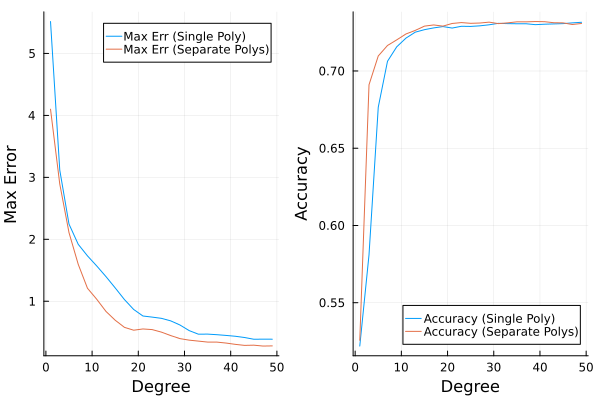

In [12]:
p_max_err = plot(degrees, max_errs_single, label="Max Err (Single Poly)", xlabel="Degree", ylabel="Max Error")
plot!(degrees, max_errs, label="Max Err (Separate Polys)")

p_acc = plot(degrees, accs_single, label="Accuracy (Single Poly)", xlabel="Degree", ylabel="Accuracy")
plot!(degrees, accs, label="Accuracy (Separate Polys)")

plot(p_max_err, p_acc, layout=(1,2))

## MNIST

In [5]:
nn = load_network("../networks/mnist/mnist_256x4_1e4.onnx")
nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), 50, max_polys_per_layer=1, verbosity=1)
nn_poly_ps = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), 50, max_polys_per_layer=Inf, verbosity=0)

Found input input
op: flatten, weight: nothing, bias: nothing


┌ Warning: Flatten layer is not supported
└ @ VNNLib.NNLoader /home/philipp/.julia/packages/VNNLib/Oj1Tb/src/NNLoader/Main.jl:83


op: gemm, weight: (256, 784), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (256, 256), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (256, 256), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (256, 256), bias: (256,)
op: relu, weight: nothing, bias: nothing
op: gemm, weight: (10, 256), bias: (10,)
--- layer 1 ---
lower = [0.0, 0.0, 0.0, 0.0, 0.0]
upper = [1.0, 1.0, 1.0, 1.0, 1.0]
--- layer 2 ---
lower = [-0.03516253067573416, -4.180390461351635, -0.0414179974113722, -0.03547903354910886, -0.5818735467182705]
upper = [0.037128060079339775, 0.10925236971979757, 0.04384775429525689, 0.037085272194417485, 0.031826429766169895]
max error = 0.0342061983064994 at idx 1 with bounds -11.528829165699108 12.457069465071072


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.04037156582444368, u = 0.04387667139963014, cs = [-6.756026428482132e-6, 0.08155431234127032, -2.027142122999447e-5, -5.4600072895497065e-5, 1.671188516074274e-8, 1.6633029732731757e-8, -5.6494633571829205e-12, -3.195239302907749e-12, 2.6149758517266703e-13, -5.499145238924133e-13, 2.5458902020042063e-13, -5.51561773528142e-13, 2.7796349253141155e-13, -5.612080673949695e-13, 2.387754236974247e-13, -5.41559673739997e-13, 2.321040626727233e-13, -5.134641839530075e-13, 2.549827128633598e-13, -4.932128969313583e-13, 2.1323152359617904e-13, -5.477698048666943e-13, 1.337039584328309e-13, -4.3448515291835694e-13, 1.7894072792921372e-13, -5.156879709612412e-13, 3.059436748439e-13, -5.457963998030912e-13, 2.9486921554289565e-13, -4.83345871613343e-13, 3.9432685404892586e-13, -4.998513129633451e-13, 4.468724701790371e-13, -4.73969726686775e-13, 5.055804471964097e-13, -5.096458592973882e-13, 3.5233681358456436e-13, -4.448

--- layer 3 ---


...

┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.02413509471342923, u = 0.015471903811594145, cs = [-7.520510090538941e-8, 0.009300588058770133, -2.2561774527629003e-7, -8.061563925705752e-8, 8.389168067000603e-12, -3.904939906435136e-12, 2.8491249746596026e-12, -4.231893269261818e-12, 2.8306805891366295e-12, -3.935437613804428e-12, 2.605647873363944e-12, -4.100259782307591e-12, 2.6185981866034783e-12, -3.826453159528867e-12, 2.643377573841029e-12, -3.285679473344681e-12, 3.3766680377938754e-12, -4.0544010973295e-12, 3.489128333718142e-12, -4.246133007629098e-12, 2.9767780623064396e-12, -3.645148774175388e-12, 2.2562697257069e-12, -3.308440629947498e-12, 2.0022529755409713e-12, -3.140254743719781e-12, 1.772398931029758e-12, -3.7743155347982745e-12, 8.763045292084814e-13, -2.8952639694480738e-12, 1.8712922321316555e-12, -2.58243822106452e-12, 1.6453625249657554e-12, -2.42456773585877e-12, 1.769315523115583e-12, -9.54959462000978e-13, 2.1695979323375496e-12, -3

--- layer 9 ---


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.04342861071620519, u = 0.03851114722743464, cs = [-3.061357533309744e-7, 0.012002392958845327, -9.184154960084005e-7, -1.7317623419059895e-7, 3.516815926882037e-11, 1.9475705269886854e-12, 4.751969111481969e-12, 9.069874153097437e-13, 4.68557774107537e-12, 8.220064611892967e-13, 4.6436292343858125e-12, 8.79455320479905e-13, 4.333026014957061e-12, 6.576810448033304e-13, 4.5669404269365564e-12, 1.0249201679666902e-12, 4.430363893528695e-12, 1.4199081741081552e-12, 3.6997336368337045e-12, 2.1096196678178535e-12, 3.6250772182744474e-12, 3.3333887647819424e-12, 4.437707592051221e-12, 3.891997625827508e-12, 3.519013616735089e-12, 3.964188079200235e-12, 2.303645060516325e-12, 2.8157528637587363e-12, 1.994884540347839e-12, 1.7732186587453967e-12, 2.47582904727695e-12, 4.204606135627723e-13, 3.0865483594620623e-12, -2.6285562977306604e-13, 3.2162147706439304e-12, -2.066533023349899e-13, 2.7619081074330587e-12, 4.6647389

lower = [0.21411972765076648, -19.56281342314196, 0.20162123882588207, 0.21444632202891575, -10.38952272586578]
upper = [0.23851494595538897, 53.36019009779771, 0.250149304735129, 0.256997560492373, 31.244263477689195]


Network(Layer[Dense{Float32, Adjoint{Float32, Base.ReshapedArray{Float32, 2, Base.ReinterpretArray{Float32, 1, UInt8, Vector{UInt8}, false}, Tuple{}}}, Base.ReinterpretArray{Float32, 1, UInt8, Vector{UInt8}, false}}(Float32[-0.0003801771 -4.841215f-6 … 0.0004506546 -0.00022187836; 3.7874255f-5 0.00011331283 … 5.9664555f-5 9.1568356f-5; … ; 0.0001204156 0.00010237807 … -5.8376674f-5 -8.800079f-5; -3.618829f-5 2.6539405f-5 … -0.00010940937 8.683106f-5], Float32[5.357947f-5, -0.011604446, -1.580469f-5, -1.590158f-5, -0.012993222, 0.0027697135, 0.00019727921, 1.7287417f-5, 0.00010886912, -0.001721526  …  -0.012317988, -4.520234f-6, 2.2818818f-5, -1.0354297f-6, -1.8209681f-5, -0.025091257, -0.0005246656, 0.000244161, 0.0027211416, -0.00064625667]), ChebyshevPoly{Float64, SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}([0.012000596468824192 0.018698242165687648 … 0.00010752734533926008 1.3001021064404921e-5; 0.007410642175168014 0.014670516192683267 

In [15]:
nn_poly2 = merge_normalization_into_dense(nn_poly)

Network(Layer[Dense{Float64, Matrix{Float64}, Vector{Float64}}([-3.170005134174014e-5 -4.036717494899375e-7 … 3.7576628048159575e-5 -1.8500733814603245e-5; 3.1580434651189926e-6 9.448287380570467e-6 … 4.974969329174556e-6 7.635182426605413e-6; … ; 1.004053269140333e-5 8.536521648521609e-6 … -4.8675828270197954e-6 -7.33771019759477e-6; -3.017463640746541e-6 2.212917268786719e-6 … -9.122807480183453e-6 7.2401756736806874e-6], [-0.038694949675063504, -0.039667022945069165, -0.03870073508775512, -0.03870074316669276, -0.03978282232681853, -0.03846847210229388, -0.03868296765684116, -0.038697975790960404, -0.03869033949556785, -0.038842962099308695  …  -0.039726519744814, -0.03869979416361953, -0.038697514569861945, -0.038699503592522604, -0.03870093562152948, -0.04079158460252352, -0.03874316509185806, -0.03867905854427485, -0.03847252214565257, -0.0387533036395689]), ChebyshevPoly{Float64, Vector{Float64}}([4.052246461552418 6.291880328008505 … 0.03519011371384711 -0.005990603969958378; 4

In [16]:
xs = rand(5, 784)
ys = [nn(xs[i,:]) for i in 1:5];
ys_poly = [nn_poly(xs[i,:]) for i in 1:5];
ys_poly2 = [nn_poly2(xs[i,:]) for i in 1:5];
ys_poly_ps = [nn_poly_ps(xs[i,:]) for i in 1:5];

# just sanity check 
@show first.(ys)
@show first.(ys_poly)
@show first.(ys_poly2);
println("------")
@show first.(ys_poly_ps);

first.(ys) = [2.9571701283882383, 1.8137367663056674, 3.5214891171122353, 0.09095650958867613, 1.659121216329648]
first.(ys_poly) = [1.718198371102048, 0.8351510353069534, 1.9749715668771943, -0.5330190847111943, 0.46700301548130885]
first.(ys_poly2) = [1.7181983711020543, 0.8351510353069526, 1.974971566877186, -0.533019084711199, 0.46700301548130885]
------
first.(ys_poly_ps) = [3.2109535553100073, 1.9925415817263554, 3.488799937197607, -0.08510481474747307, 1.467782818755525]


In [17]:
params_nn_poly2 = convert_to_list_of_tuples(nn_poly2)
@save "mnist_256x4_1e4_single_poly.jld2" params=params_nn_poly2

### Mini-Experiment: Effect of only a single Polynomial

In [11]:
using VeryDiffPolyExperiments: load_mnist_data, acc_fun, max_fun, mae_fun, mse_fun, evaluate_network

In [7]:
X_test, y_labels = load_mnist_data()
y_labels = y_labels .+ 1  # convert to 1-based indexing

60000-element Vector{Int64}:
  6
  1
  5
  2
 10
  3
  2
  4
  2
  5
  ⋮
  3
 10
  6
  2
  9
  4
  6
  7
  9

In [12]:
ŷ = [nn(x) for x in X_test]
ŷ = hcat(ŷ...)'
original_acc = acc_fun(y_labels, ŷ)
println("Original accuracy: $original_acc")

max_errs_single = []
maes_single = []
mses_single = []
accs_single = []

degrees = 1:5:100
for d in degrees
    nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=1, verbosity=0)
    max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
    push!(max_errs_single, max_err)
    push!(maes_single, mae)
    push!(mses_single, mse)
    push!(accs_single, acc)
    println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
end

max_errs = []
maes = []
mses = []
accs = []

for d in degrees
    nn_poly = approximate_polynomial_iterative(nn, Zonotope(zeros(784), ones(784)), d, max_polys_per_layer=Inf, verbosity=0)
    max_err, mae, mse, acc, _ = evaluate_network(nn_poly, X_test, ŷ, y_labels, max_fun, mae_fun, mse_fun, acc_fun)
    push!(max_errs, max_err)
    push!(maes, mae)
    push!(mses, mse)
    push!(accs, acc)
    println("Degree $d: max err = $max_err, mae = $mae, mse = $mse, acc = $acc")
end

Original accuracy: 0.9864166666666667
Degree 1: max err = 66.73455132760887, mae = 55.40160165661506, mse = 13632.033211755928, acc = 0.11276666666666667


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.01318391233769233, u = 0.012977010833417032, cs = [-1.6990424477312653e-10, 0.0014764387759926775, -5.098160006557999e-10, -2.848340187795763e-10, 2.829214696447776e-14, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.017724827773151923, u = 0.019595946283384416, cs = [-4.3808376890860864e-10, 0.0021062635189875827, -1.3143336098696499e-9, -8.270533846413103e-10, 3.966416569828934e-14, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.01083459504658858, u = 0.021156254248506073, cs = [-5.970255028274062e-10, 0.0018054589489801883, -1.7911793563985843e-9, -5.207047211475591e-10, 4.6272524

Degree 6: max err = 20.51176801293623, mae = 13.316477493669632, mse = 405.98155095304287, acc = 0.5493


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.020979271820598194, u = 0.03362151190323598, cs = [-1.8837682103082226e-8, 0.000864454903378214, -5.651335808901521e-8, -4.9125647006482605e-11, 6.235595370580021e-13, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.0191201129201539, u = 0.0400664749100151, cs = [-2.2152940556402474e-8, 0.0009370213281101906, -6.645888413731217e-8, -6.196648411188832e-11, -5.502351672834773e-13, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.02349656883056922, u = 0.050556775669269985, cs = [-3.469969563097339e-8, 0.001172352111537228, -1.0409908870447845e-7, -1.2296007992975192e-10, -6.19677864127700

Degree 11: max err = 13.846943217686563, mae = 8.634391081849875, mse = 143.54226172255215, acc = 0.7841166666666667


...

┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.03581118286908355, u = 0.039680776238074436, cs = [-1.0896841428503496e-7, 0.004585057593863534, -3.269060905495481e-7, -9.537685213878206e-9, 2.7130003855256028e-12, 3.0371037872863796e-12, 1.1877255172564334e-12, 3.3564450820204207e-12, 1.203412458050386e-12, 3.851704212800933e-12, 1.6067909356091748e-12, 3.1710030319204776e-12, 1.6899877466056751e-12, 2.1289419648936066e-12, 1.6462884115368063e-12, 1.885794382587337e-12, 1.4992233415934978e-12, 5.143075588874555e-13, 4.896566519255295e-13, -6.050677163381829e-13, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.04914929007539806, u = 0.033443404789467265, cs = [-1.245073430192234e-7, 0.005016682175067399, -3.735234291131368e-7, -1.2500520425217512e-8, 4.441540926126564e-12, -2.576795289129978e-12

Degree 26: max err = 7.369843516802929, mae = 3.993865625952426, mse = 39.81421947918062, acc = 0.9786666666666667


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.02697007393555602, u = 0.026073386792693574, cs = [-6.702528393358047e-8, 0.0039962068287546755, -2.0107500083743725e-7, -6.350737911378729e-9, -1.933167730422815e-12, -1.916906387808281e-12, -2.4725290943702145e-12, -2.1043143363559745e-12, -2.5063398067370665e-12, -2.1223467162849623e-12, -2.1933492122553513e-12, -1.2432681947468122e-12, -2.926558660439369e-12, -4.646557899558794e-13, -3.2070265696920167e-12, -3.1138056055948407e-13, -2.622584255922148e-12, 5.206849704495195e-13, -7.230662344739621e-13, 3.844761006287732e-13, 3.55817496813059e-14, -1.2899591784915126e-12, 3.635456596397696e-13, -1.3253799247805957e-12, -2.3989505441242557e-12, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -0.03502348718799765, u = 0.023813444441927664, cs = [-7.94

Degree 31: max err = 6.332491374433882, mae = 3.0947323265938893, mse = 25.348352886075467, acc = 0.9816166666666667


┌ Warning: Chebyshev polynomial has almost zero leading coefficient. l = -4.35223740871389, u = 10.818837231744372, cs = [-0.09346350690770708, 0.6030354848136286, -0.2898819370343372, -0.07384874282688692, 0.04883135170005045, 0.0047851176132514975, -0.003269013480321739, -0.00012848707558407043, 0.00011376129698588129, 6.291426298183129e-7, -2.3332038971013738e-6, 4.275401517799395e-8, 2.9980743135910436e-8, -1.1353625009885014e-9, -2.4600783598051207e-10, 1.3916296144553151e-11, 1.2306684757516794e-12, -1.928105995991655e-13, -2.4150898667176264e-14, -8.272295383014267e-14, -3.2619033839980854e-14, -7.683076343336516e-14, -2.7503026216625004e-14, -7.888736450454808e-14, -9.346770295272778e-15, -6.740892436621035e-14, -8.70939393023675e-15, -5.961404748714011e-14, -4.1075365746766265e-15, -4.967286471514114e-14, 0.0].
│ Truncating to last non-zero coefficient.
└ @ VeryDiff /home/philipp/.julia/packages/VeryDiff/zFZtJ/src/chebyshev/Chebyshev.jl:209
┌ Warning: Chebyshev polynomial has 

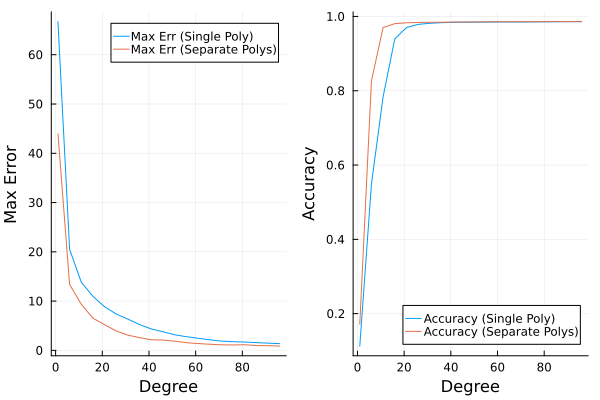

In [13]:
p_max_err = plot(degrees, max_errs_single, label="Max Err (Single Poly)", xlabel="Degree", ylabel="Max Error")
plot!(degrees, max_errs, label="Max Err (Separate Polys)")

p_acc = plot(degrees, accs_single, label="Accuracy (Single Poly)", xlabel="Degree", ylabel="Accuracy")
plot!(degrees, accs, label="Accuracy (Separate Polys)")

plot(p_max_err, p_acc, layout=(1,2))